In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

Como é a malha municipal do Ceará que vamos usar pros mapas?

Total de municípios: 184
Geometrias inválidas antes: 5
Geometrias inválidas depois: 0


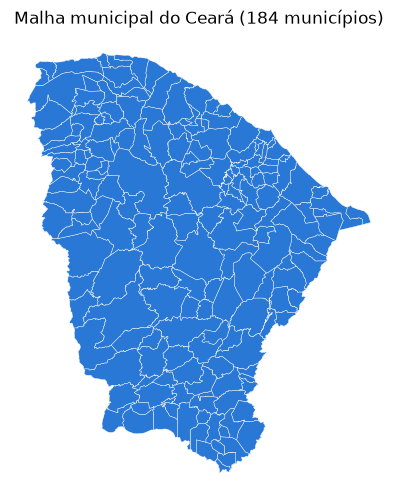

In [2]:
gdf_municipios = gpd.read_file("../dados/raw/malha_municipal_ce_2022.geojson")

print(f"Total de municípios: {gdf_municipios.shape[0]}")
print(f"Geometrias inválidas antes: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios["geometry"] = gdf_municipios["geometry"].make_valid()

print(f"Geometrias inválidas depois: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios.plot(figsize=(6, 6), color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.3)
plt.title("Malha municipal do Ceará (184 municípios)")
plt.axis("off")
plt.show()

Qual foi o valor da produção agrícola de cada município do Ceará, e como junto isso com a malha?

In [3]:
df_pam_raw = pd.read_csv("../dados/processed/pam_tratado.csv")

valor_municipios_geo = df_pam_raw[
    (df_pam_raw["nivel_territorial_nome"] == "Município")
    & (df_pam_raw["unidade"] == "Mil Reais")
].copy()
valor_municipios_geo["territorio_codigo"] = valor_municipios_geo["territorio_codigo"].astype(str)

valor_municipios_geo_pivot = valor_municipios_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

print(f"Municípios com valor da produção: {valor_municipios_geo_pivot.shape[1]}")
valor_municipios_geo_pivot.head()

Municípios com valor da produção: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,3093.0,1589.0,10595.0,5352.0,2808.0,3084.0,630.0,3341.0,9832.0,594.0,...,9218.0,2559.0,5874.0,1057.0,915.0,5219.0,1857.0,2589.0,2433.0,9931.0
2004,1775.0,2015.0,8355.0,6136.0,1423.0,2496.0,447.0,4758.0,9586.0,326.0,...,8248.0,2582.0,5968.0,621.0,775.0,9729.0,1469.0,1937.0,1357.0,11870.0
2005,689.0,2073.0,6028.0,1069.0,3041.0,2520.0,481.0,2837.0,7329.0,303.0,...,7261.0,2152.0,5386.0,340.0,1212.0,7306.0,1604.0,1828.0,1186.0,10706.0
2006,1686.0,2097.0,9945.0,7737.0,5347.0,2739.0,681.0,4524.0,10419.0,1082.0,...,9900.0,3203.0,5226.0,978.0,1617.0,9277.0,1900.0,2191.0,3149.0,11787.0
2007,2059.0,2433.0,5202.0,3632.0,3203.0,2887.0,575.0,3041.0,5678.0,529.0,...,4885.0,1431.0,6932.0,526.0,1323.0,9991.0,2445.0,1976.0,985.0,18415.0


In [4]:
gdf_valor = gdf_municipios.merge(
    valor_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios = (
    valor_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_valor.insert(1, "nome", gdf_valor["codarea"].map(nomes_municipios))

nao_casaram = gdf_valor[gdf_valor[2023].isna()]
print(f"Municípios sem valor casado: {len(nao_casaram)}")
gdf_valor.head()

Municípios sem valor casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",3093.0,1775.0,689.0,1686.0,2059.0,2642.0,2674.0,...,684.0,367.0,4547.0,3736.0,1621.0,5461.0,6895.0,9201.0,5499.0,6038.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",1589.0,2015.0,2073.0,2097.0,2433.0,3933.0,2041.0,...,1061.0,882.0,1160.0,1364.0,1246.0,1831.0,2449.0,2155.0,1016.0,1672.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",10595.0,8355.0,6028.0,9945.0,5202.0,10823.0,6823.0,...,12741.0,15083.0,24379.0,20322.0,9904.0,18346.0,25087.0,33142.0,22175.0,70844.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",5352.0,6136.0,1069.0,7737.0,3632.0,10128.0,2880.0,...,3684.0,5410.0,4192.0,5768.0,7436.0,16818.0,37469.0,37747.0,15927.0,11143.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",2808.0,1423.0,3041.0,5347.0,3203.0,7346.0,4331.0,...,3692.0,2191.0,5246.0,3659.0,4051.0,11336.0,9354.0,6886.0,6781.0,10855.0


Qual o valor da produção agrícola de cada município do Ceará, no mapa, em 2023?

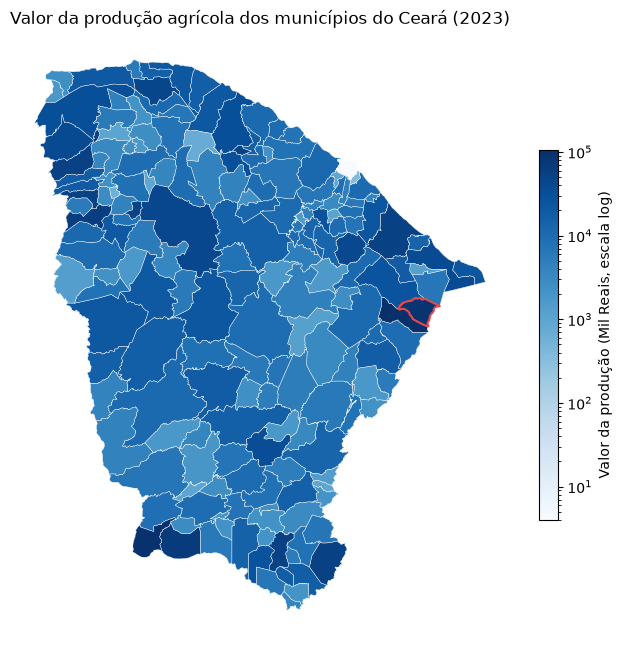

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_valor.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_valor[2023].min(), vmax=gdf_valor[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Valor da produção (Mil Reais, escala log)", "shrink": 0.6},
    ax=ax,
)

quixere = gdf_valor[gdf_valor["nome"] == "Quixeré - CE"]
quixere.plot(ax=ax, facecolor="none", edgecolor="#e34948", linewidth=1.5)

ax.set_title("Valor da produção agrícola dos municípios do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

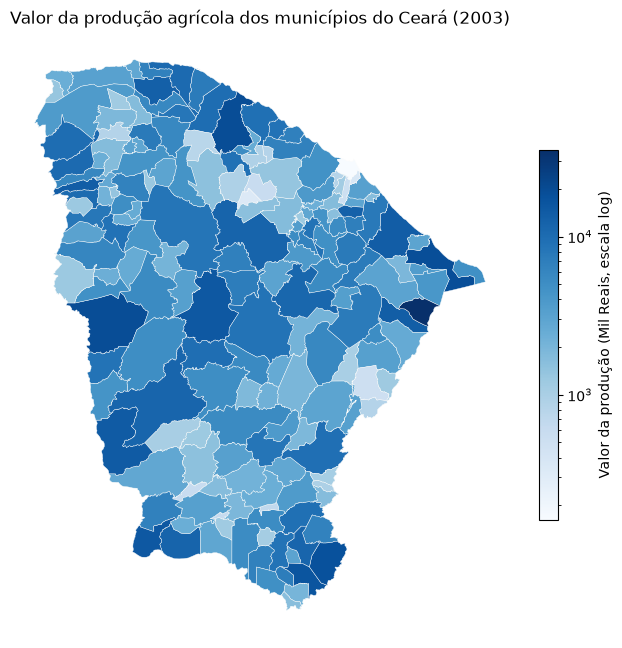

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_valor.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_valor[2003].min(), vmax=gdf_valor[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Valor da produção (Mil Reais, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Valor da produção agrícola dos municípios do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em valor de produção (2003 -> 2023), no mapa?

In [7]:
gdf_valor["crescimento"] = gdf_valor[2023] / gdf_valor[2003]

ranking = gdf_valor[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking.index += 1

print("Ranking de crescimento do valor da produção por município (2003 -> 2023):")
for pos, row in ranking.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

Ranking de crescimento do valor da produção por município (2003 -> 2023):
  1. Varjota - CE                     19.4x
  2. Apuiarés - CE                    16.2x
  3. Umirim - CE                      10.6x
  4. Palhano - CE                      9.7x
  5. Uruburetama - CE                  9.6x
  6. Itaitinga - CE                    8.7x
  7. Russas - CE                       8.4x
  8. Granja - CE                       8.3x
  9. Paramoti - CE                     8.2x
 10. Limoeiro do Norte - CE            7.7x
 11. Pacatuba - CE                     7.6x
 12. Guaraciaba do Norte - CE          7.6x
 13. General Sampaio - CE              6.9x
 14. Tururu - CE                       6.6x
 15. Camocim - CE                      6.5x
 16. Salitre - CE                      6.4x
 17. Redenção - CE                     6.1x
 18. Missão Velha - CE                 6.0x
 19. Caridade - CE                     5.8x
 20. Araripe - CE                      5.5x
 21. Alto Santo - CE                   5.4x
 2

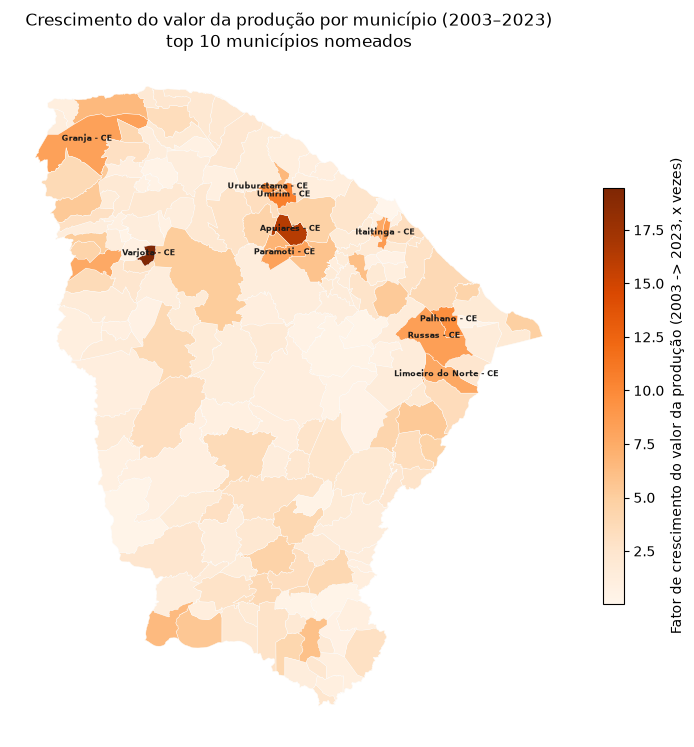

In [8]:
top10 = gdf_valor.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_valor.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do valor da produção (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do valor da produção por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

Existe diferença de perda de safra (área plantada x área colhida) entre os municípios do Ceará, no mapa?

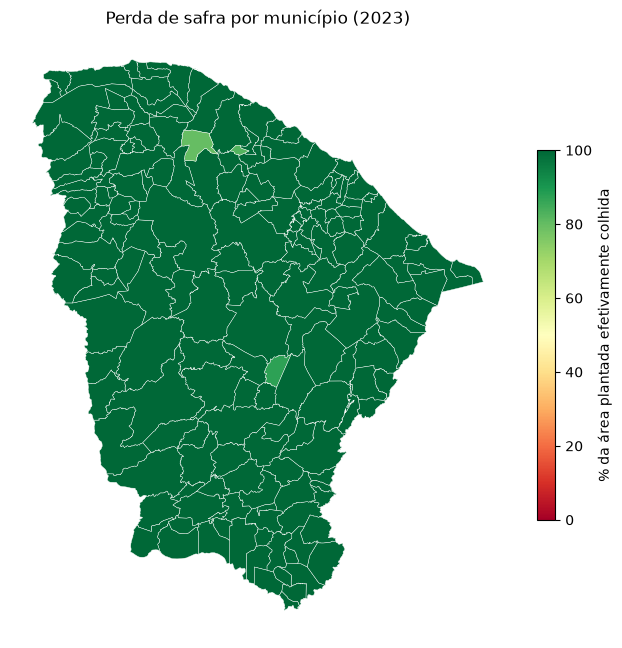

In [9]:
colhida_geo = df_pam_raw[
    (df_pam_raw["nivel_territorial_nome"] == "Município") & (df_pam_raw["variavel_nome"] == "Área colhida")
].copy()
colhida_geo["territorio_codigo"] = colhida_geo["territorio_codigo"].astype(str)
colhida_pivot = colhida_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

plantada_geo = df_pam_raw[
    (df_pam_raw["nivel_territorial_nome"] == "Município") & (df_pam_raw["variavel_nome"] == "Área plantada ou destinada à colheita")
].copy()
plantada_geo["territorio_codigo"] = plantada_geo["territorio_codigo"].astype(str)
plantada_pivot = plantada_geo.groupby(["ano_nome", "territorio_codigo"])["valor"].sum().unstack("territorio_codigo")

ano_perda_geo = 2023
perda_safra_geo = (colhida_pivot.loc[ano_perda_geo] / plantada_pivot.loc[ano_perda_geo] * 100).rename("pct_colhida")

gdf_perda_safra = gdf_municipios.merge(perda_safra_geo, left_on="codarea", right_index=True, how="left")

fig, ax = plt.subplots(figsize=(8, 8))
gdf_perda_safra.plot(
    column="pct_colhida",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "% da área plantada efetivamente colhida", "shrink": 0.6},
    ax=ax,
)

ax.set_title(f"Perda de safra por município ({ano_perda_geo})")
ax.axis("off")
plt.show()